### Context_precision

### PART 1: create metadata with LLM and save in .json

In [7]:
import os
import json
import time
import requests
from pathlib import Path
import fitz

In [ ]:
DATA_DIR = Path("data")
PDF_DIR = Path("pdfs")

DATA_DIR.mkdir(exist_ok=True)

META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"

api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError("Missing GEMINI_API_KEY environment variable")

if META_CACHE_PATH.exists():
    with META_CACHE_PATH.open("r", encoding="utf-8") as f:
        metadata_cache = json.load(f)
else:
    metadata_cache = {}

In [ ]:
def extract_text_from_pdf(pdf_path: Path) -> str:
    doc = fitz.open(pdf_path)
    text = "".join(page.get_text() for page in doc)
    doc.close()
    return text


def extract_llm_metadata(doc_text: str) -> dict:
    """
    Calls Gemini and returns structured metadata as JSON
    """

    snippet = doc_text[:12000]  # no cal enviar-ho tot

    prompt = f"""
        You are extracting bibliographic and topical metadata from a PDF text dump.
        Return ONLY valid JSON (no markdown).

        Schema:
        {{
        "title": string|null,
        "authors": [string],
        "year": int|null,
        "keywords": [string],
        "topics": [string],
        "one_sentence_summary": string|null
        }}

        Rules:
        - If unsure, use null or empty lists
        - Do not hallucinate author names
        - Base everything strictly on the provided text

        TEXT:
        {snippet}
        """.strip()

    url = (
        "https://generativelanguage.googleapis.com/v1beta/"
        "models/gemini-2.5-flash:generateContent"
    )

    headers = {
        "Content-Type": "application/json",
        "x-goog-api-key": api_key
    }

    payload = {
        "contents": [
            {"parts": [{"text": prompt}]}
        ]
    }

    response = requests.post(url, headers=headers, json=payload)
    response.raise_for_status()

    data = response.json()
    raw = data["candidates"][0]["content"]["parts"][0]["text"]

    raw = raw.strip().replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(raw)
    except json.JSONDecodeError as e:
        print("\n=== JSON PARSE FAILED ===")
        print("Error:", e)
        print("RAW OUTPUT:\n", raw)
        print("========================\n")
        raise


def build_metadata_cache(pdf_paths):
    for pdf_path in pdf_paths:
        pdf_name = pdf_path.name

        if pdf_name in metadata_cache:
            print(f"Cached: {pdf_name}")
            continue

        print(f"Processing: {pdf_name}")

        text = extract_text_from_pdf(pdf_path)
        metadata = extract_llm_metadata(text)

        metadata_cache[pdf_name] = metadata

        META_CACHE_PATH.write_text(
            json.dumps(metadata_cache, indent=2, ensure_ascii=False),
            encoding="utf-8"
        )

        time.sleep(4)  # rate limiting

In [ ]:
pdf_paths = list(PDF_DIR.glob("*.pdf"))

build_metadata_cache(pdf_paths)

print("Metadata cache created:", META_CACHE_PATH)

### PART 2: read llm_metadata_cache.json and create embeddings

In [8]:
import json
from pathlib import Path

BASE_DIR = Path.cwd().parents[0]   # backend/
PDF_EXAMPLES = BASE_DIR/ "example_pdfs_to_upload"

DATA_DIR = BASE_DIR / "data"
META_CACHE_PATH = DATA_DIR / "llm_metadata_cache.json"

if not META_CACHE_PATH.exists():
    raise RuntimeError("llm_metadata_cache.json not found. Metadata must be precomputed.")

with META_CACHE_PATH.open("r", encoding="utf-8") as f:
    metadata_cache = json.load(f)


In [9]:
def build_metadata_string(llm_meta):

    if not llm_meta:
        return ""
    parts = []
    if llm_meta.get("title"):
        parts.append(f"Title: {llm_meta['title']}")
    if llm_meta.get("topics"):
        parts.append("Topics: " + ", ".join(llm_meta["topics"]))
    if llm_meta.get("keywords"):
        parts.append("Keywords: " + ", ".join(llm_meta["keywords"]))
    if llm_meta.get("one_sentence_summary"):
        parts.append("Summary: " + llm_meta["one_sentence_summary"])
    return "[METADATA]\n" + "\n".join(parts)

def get_llm_metadata(pdf_name: str) -> dict:
    """
    Read-only metadata accessor.
    No LLM calls. No side effects.
    """
    return metadata_cache.get(pdf_name, {})

In [10]:
import fitz  # PyMuPDF
from embedder import Embedder

class DataManager:
    """
    Handles:
    - PDF text extraction
    - Chunking
    - Embedding (baseline / concat / dual)
    """

    def __init__(self, pdf_folder, metadata_mode="concat"):
        self.embedder = Embedder()
        self.pdf_folder = pdf_folder
        self.metadata_mode = metadata_mode
        self.tokenizer = self.embedder.model.tokenizer

    # ------------------------------
    # PDF TEXT EXTRACTION
    # ------------------------------
    def extract_text(self, pdf_path):
        doc = fitz.open(pdf_path)
        text = "".join(page.get_text() for page in doc)
        doc.close()
        return text

    # ------------------------------
    # CHUNKING
    # ------------------------------
    def chunk_text(self, text, chunk_size=400, chunk_overlap=50):
        tokens = self.tokenizer.encode(text, add_special_tokens=False)

        chunks = []
        step = chunk_size - chunk_overlap

        for i in range(0, len(tokens), step):
            chunk_ids = tokens[i:i + chunk_size]
            chunk_text = self.tokenizer.decode(chunk_ids, skip_special_tokens=True)
            chunks.append(chunk_text)

        return chunks

    # ------------------------------
    # MAIN PIPELINE
    # ------------------------------
    def process_pdf(self, pdf_path, mode="baseline"):
        text = self.extract_text(pdf_path)
        chunks = self.chunk_text(text)

        llm_meta = {}
        meta_str = ""

        if mode in ("concat", "dual"):
            llm_meta = get_llm_metadata(pdf_path.name)
            meta_str = build_metadata_string(llm_meta)

        if mode == "dual":
            emb_meta = self.embedder.encode(meta_str)

        chunk_records = []

        for chunk in chunks:
            if mode == "baseline":
                emb = self.embedder.encode(chunk)
                chunk_records.append({
                    "text": chunk,
                    "embedding": emb
                })

            elif mode == "concat":
                emb = self.embedder.encode(chunk + "\n\n" + meta_str)
                chunk_records.append({
                    "text": chunk,
                    "embedding": emb
                })

            elif mode == "dual":
                emb_text = self.embedder.encode(chunk)
                chunk_records.append({
                    "text": chunk,
                    "embedding_text": emb_text,
                    "embedding_meta": emb_meta
                })

        return {
            "pdf_name": pdf_path.name,
            "llm_metadata": llm_meta,
            "chunks": chunk_records
        }

    # ------------------------------
    # INDEX BUILDING
    # ------------------------------
    def build_index(self, pdf_paths, mode="baseline"):
        database = []

        for pdf_path in pdf_paths:
            entry = self.process_pdf(pdf_path, mode=mode)
            print(f"Indexed: {pdf_path.name}")
            database.append(entry)

        return database


In [11]:
import numpy as np

class BaselineRetriever:
    def __init__(self, database=None, embedder=None, mode="not_dual"):
        self.embedder = embedder or Embedder()
        self.database = database or []
        self.mode = mode  # "not_dual" or "dual"

    def cosine_similarity(self, v1, v2):
        v1 = np.array(v1)
        v2 = np.array(v2)
        return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

    def search(self, query, threshold=0.70, alpha=0.7):
        query_emb = self.embedder.encode(query)
        results = []

        for entry in self.database:
            best_score = 0.0
            best_chunk = None

            for chunk in entry.get("chunks", []):
                if self.mode == "dual":
                    s_text = self.cosine_similarity(query_emb, chunk["embedding_text"])
                    s_meta = self.cosine_similarity(query_emb, chunk["embedding_meta"])
                    score = alpha * s_text + (1 - alpha) * s_meta
                else:
                    score = self.cosine_similarity(query_emb, chunk["embedding"])

                if score > best_score:
                    best_score = score
                    best_chunk = chunk

            if best_score >= threshold:
                results.append({
                    "paper_id": entry.get("pdf_name", ""),
                    "title": entry.get("llm_metadata", {}).get("title", entry.get("pdf_name", "")),
                    "pdf_name": entry.get("pdf_name", ""),
                    "score": round(best_score, 3),
                    "sample_text": best_chunk["text"][:300] if best_chunk else ""
                })

        results.sort(key=lambda x: x["score"], reverse=True)
        return results


In [12]:
embedder = Embedder()
dm = DataManager(pdf_folder=PDF_EXAMPLES)

pdf_paths = list(PDF_EXAMPLES.glob("*.pdf"))

baseline_db = dm.build_index(pdf_paths, mode="baseline")
concat_db   = dm.build_index(pdf_paths, mode="concat")
dual_db     = dm.build_index(pdf_paths, mode="dual")

baseline_retriever = BaselineRetriever(baseline_db, embedder)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: ebfe61b0-3f58-498d-a0a2-ac0e7edf1718)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./config_sentence_transformers.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 8b45a7f0-000d-412c-9fec-82c338dbb07f)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 67a51f42-fec3-4fcd-8952-983c4e6ed547)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/./README.md
Retrying in 1s [Retry 1/5].
Token indices sequence length is longer tha

Indexed: 2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf
Indexed: 2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf
Indexed: 2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf
Indexed: 2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf
Indexed: 2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf
Indexed: 2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf
Indexed: 2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf
Indexed: 2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf
Indexed: 2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf
Indexed: 2025-12-04_Alice-Rober

In [13]:
concat_retriever   = BaselineRetriever(concat_db, embedder)

In [14]:
dual_retriever     = BaselineRetriever(dual_db, embedder, mode="dual")

### PART 3: run evaluation

#### 3.1 Hit_rate@k

In [69]:
queries_easy = {
    "GDPR compliance and neuroimaging data privacy": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "bottleneck fusion for multimodal medical data integration": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory clinical metrics for alzheimers disease classification": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "tau protein biomarkers and hippocampal atrophy correlation": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "hyperparameter sweep and weights and biases tracking": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "docker environment setup for local hardware clusters": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "synthetic data generation and smote for class imbalance": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "weekly team sync and tau protein data audit": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "scaled dot product attention mechanism": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "deep residual learning for image recognition": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "vision transformer using image patches": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "retrieval augmented generation for nlp tasks": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adam optimizer for stochastic optimization": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "taxonomy of multimodal machine learning": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "pathological network model for alzheimers interventions": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "graph model of tau pathology spreading": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "personalized trajectories of cortical atrophy": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "pathology steered stratification for subtype identification": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "video reasoning over traffic events benchmark": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "deep counterfactuals for alzheimers prediction": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "multimodal attention for disease diagnosis": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "evaluating disease focus in deep learning models": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "explainable ai requirements for clinicians": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "transfer learning for 3d medical image analysis": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "generative adversarial networks in medical imaging review": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "success factors for scientific teams": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "monetary value of large scientific collaboration": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher perceptions of llm tools": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [68]:
queries_intermediate = {
    "distinction between pseudonymization and anonymization under gdpr": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "kl divergence for latent space regularization": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "area under the precision recall curve for imbalanced data": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "k-nearest neighbors imputation for missing tau protein values": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "optimal batch size and learning rate interaction in adamw": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "solving numpy and scipy version mismatch for linear algebra": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "elastic transformations for simulating anatomical variability": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "dynamic masking for incomplete multimodal inputs": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "multi-head self-attention and position-wise feed-forward networks": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "shortcut connections and identity mapping for optimization": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "transformer encoder blocks for fine-grained image recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "knowledge-intensive tasks using dense vector retrieval": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "adaptive moment estimation mechanics for deep learning": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "challenges in cross-modal alignment and feature fusion": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "combinatorial intervention strategies for alzheimers networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot inverse solver for two-species graph models": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "spatiotemporal modeling of cortical atrophy trajectories": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "subtype identification in alzheimers using stratification networks": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "efficient networks for temporal reasoning in video": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "interpretable volumetric changes using deep counterfactuals": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "attention weights for integrating imaging and clinical data": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "quantitative metrics for disease focus and saliency maps": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinical requirements for explainable ai decision support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical imaging analysis using pre-trained med3d models": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "gan applications for medical image synthesis and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "link between scientific team freshness and success": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "productivity estimates of large scale scientific collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "large scale survey of researcher usage of llms": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [67]:
queries_difficult = {
    "unauthorized data transfer to neurocloud analytic solutions": "2026-01-05_Alice-Robertson_Compliance-Review.pdf",
    "intermediate fusion vs early fusion for 3d mri data": "2026-01-08_Chloe-Nguyen_Multimodal-Fusion-Logic.pdf",
    "mandatory external validation using oasis-3 dataset": "2026-01-12_Alice-Robertson_Evaluation-Standards.pdf",
    "missing tau protein data for subjects ad-102 to ad-118": "2026-01-14_Bob-Martinez_Proteomics-Integration.pdf",
    "mri encoder overfitting patterns starting at epoch 50": "2026-01-16_Chloe-Nguyen_Hyperparameter-Sweep.pdf",
    "cuda 12.1 and pytorch 2.4.0 cluster requirements": "2026-01-18_Daniel-Fischer_Environment-Setup.pdf",
    "parameters for bob's elastic transform alpha 50 and sigma 8": "2026-01-22_Bob-Martinez_Synthetic-Data-Gen.pdf",
    "audit of pet-tau tracers for 24-month follow-up window": "2026-01-27_Daniel-Fischer_Weekly-Sync.pdf",
    "square root of dk scaling factor in attention": "2025-11-10_Chloe-Nguyen_Attention-Is-All-You-Need.pdf",
    "convergence of stochastic gradient descent in deep residuals": "2025-11-12_Chloe-Nguyen_Deep-Residual-Learning-for-Image-Recognition.pdf",
    "16x16 pixel image patch size for transformer recognition": "2025-11-15_Chloe-Nguyen_An-Image-is-Worth-16x16-Words-Transformers-for-Image-Recognition-at-Scale.pdf",
    "parametric generator and non-parametric retriever synergy": "2025-11-20_Chloe-Nguyen_Retrieval-Augmented-Generation-for-Knowledge-Intensive-NLP-Tasks.pdf",
    "bias correction using first and second moment estimates": "2025-11-22_Chloe-Nguyen_Adam-A-Method-for-Stochastic-Optimization.pdf",
    "co-learning and modality representation mismatch": "2025-11-05_Alice-Robertson_Multimodal-Machine-Learning-A-Survey-and-Taxonomy.pdf",
    "dynamic interventions in pathological protein networks": "2025-11-26_Alice-Robertson_A-Systemic-Pathological-Network-Model-and-Combinatorial-Intervention-Strategies-for-Alzheimers-Disease.pdf",
    "snapshot solver for graph models of neurodegeneration": "2025-11-29_Bob-Martinez_A-single-snapshot-inverse-solver-for-two-species-graph-model-of-tau-pathology-spreading-in-human-Alzheimer-disea.pdf",
    "longitudinal modeling of atrophy in alzheimers patient cohorts": "2025-12-02_Bob-Martinez_Data-driven-spatiotemporal-modeling-reveals-personalized-trajectories-of-cortical-atrophy-in-Alzheimers-disease.pdf",
    "stratification network performance across diverse alzheimers subtypes": "2025-12-04_Alice-Robertson_Pathology-Steered-Stratification-Network-for-Subtype-Identification-in-Alzheimers-Disease.pdf",
    "temporal reasoning benchmarks for traffic event qa": "2025-12-05_Bob-Martinez_SUTD-TrafficQA-A-Question-Answering-Benchmark-and-an-Efficient-Network-for-Video-Reasoning-over-Traffic-Events.pdf",
    "quantitative interpretation of brain region volumetric changes": "2025-12-07_Bob-Martinez_A-Quantitatively-Interpretable-Model-for-Alzheimers-Disease-Prediction-Using-Deep-Counterfactuals.pdf",
    "integrated analysis of pet scans and clinical cognitive scores": "2025-12-08_Chloe-Nguyen_Multimodal-Attention-based-Deep-Learning-for-Alzheimers-Disease-Diagnosis.pdf",
    "saliency map evaluation and disease relevant features": "2025-12-10_Alice-Robertson_A-Quantitative-Approach-for-Evaluating-Disease-Focus-and-Interpretability-of-Deep-Learning-Models-for-Alzheimers.pdf",
    "clinician centered explainable ai for critical care support": "2025-12-12_Chloe-Nguyen_Exploring-the-Requirements-of-Clinicians-for-Explainable-AI-Decision-Support-Systems-in-Intensive-Care.pdf",
    "3d medical analysis using transfer learning on large scale datasets": "2025-12-14_Bob-Martinez_Med3D-Transfer-Learning-for-3D-Medical-Image-Analysis.pdf",
    "adversarial training for medical image segmentation and denoising": "2025-12-16_Chloe-Nguyen_Generative-Adversarial-Network-in-Medical-Imaging-A-Review.pdf",
    "scientific team success through fresh perspectives": "2025-12-20_Daniel-Fischer_Freshness-Persistence-and-Success-of-Scientific-Teams.pdf",
    "economic analysis of scientific productivity in large collaborations": "2025-12-22_Daniel-Fischer_The-Link-Between-Large-Scientific-Collaboration-and-Productivity-Rethinking-How-to-Estimate-the-Monetary-Value-o.pdf",
    "researcher tool usage and perceptions survey results": "2025-12-24_Daniel-Fischer_LLMs-as-Research-Tools-A-Large-Scale-Survey-of-Researchers-Usage-and-Perceptions.pdf"
}

In [36]:
def run_retrievals_once(retrievers, evaluation_pairs, max_k=10):
    """
    Runs retrieval ONCE and stores results.

    Returns:
    retrieval_cache[retriever_name][query] = [
        {"pdf_name": ..., "score": ...}, ...
    ]
    """

    retrieval_cache = {}

    for name, retriever in retrievers.items():
        retrieval_cache[name] = {}

        for query in evaluation_pairs:
            results = retriever.search(query, threshold=0.0)
            retrieval_cache[name][query] = results[:max_k]

    return retrieval_cache

In [ ]:
retrievers = {
    "Baseline": baseline_retriever,
    "Concat": concat_retriever,
    "Dual": dual_retriever}

retrieval_easy = run_retrievals_once(
    retrievers,
    queries_easy,
    max_k=10)

retrieval_intermediate = run_retrievals_once(
    retrievers,
    queries_intermediate,
    max_k=10)

retrieval_difficult = run_retrievals_once(
    retrievers,
    queries_difficult,
    max_k=10)

In [30]:
def hit_at_k_vs_threshold(retrieval_cache, evaluation_pairs, thresholds, k=3):
    hits_by_retriever = {}

    for name, results_by_query in retrieval_cache.items():
        hits_by_retriever[name] = []

        for t in thresholds:
            hits = 0
            for query, expected_pdf in evaluation_pairs.items():
                results = [
                    r for r in results_by_query[query]
                    if r["score"] >= t
                ]

                for r in results[:k]:
                    if r["pdf_name"] == expected_pdf:
                        hits += 1
                        break

            hits_by_retriever[name].append(hits)

    return hits_by_retriever


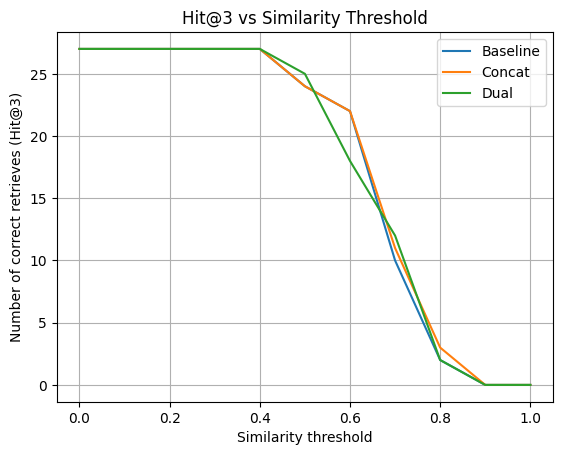

In [77]:
thresholds = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0]

hits_by_retriever = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

plt.figure()
for name, hits in hits_by_retriever.items():
    plt.plot(thresholds, hits, label=name)

plt.xlabel("Similarity threshold")
plt.ylabel("Number of correct retrieves (Hit@3)")
plt.title("Hit@3 vs Similarity Threshold")
plt.legend()
plt.grid(True)
plt.show()

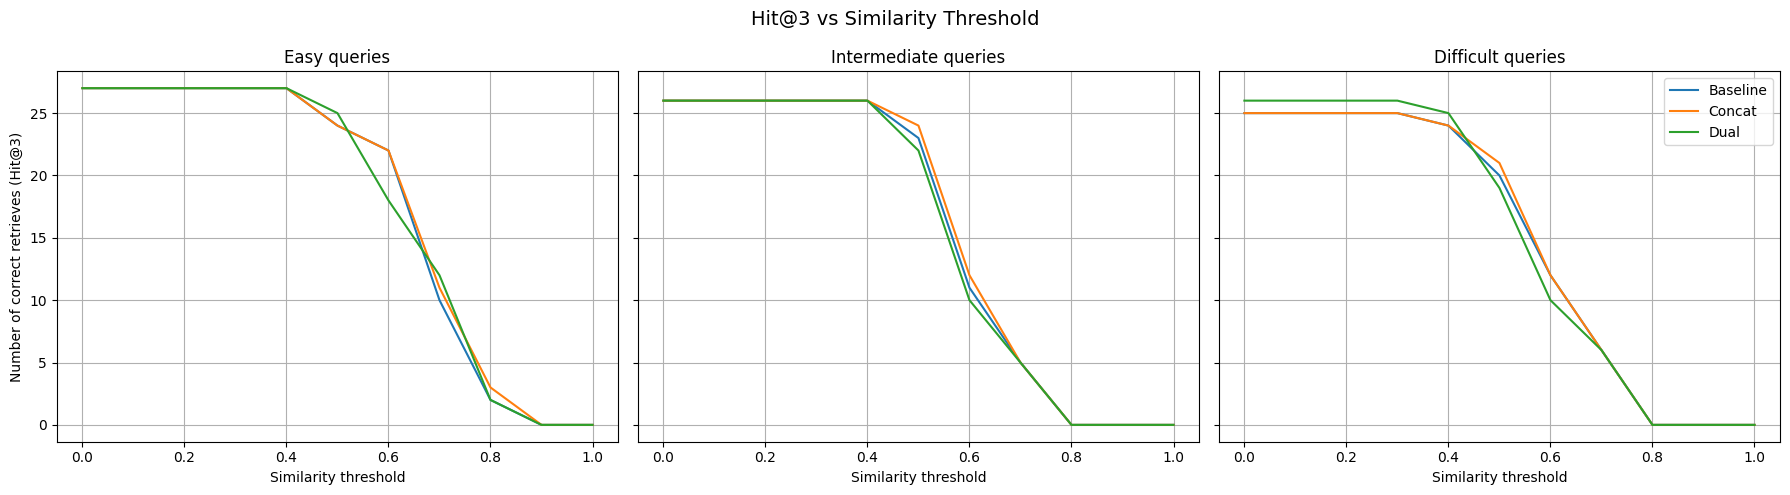

In [76]:
hits_by_retriever_easy = hit_at_k_vs_threshold(
    retrieval_easy,
    queries_easy,
    thresholds,
    k=3)

hits_by_retriever_intermediate = hit_at_k_vs_threshold(
    retrieval_intermediate,
    queries_intermediate,
    thresholds,
    k=3)

hits_by_retriever_difficult = hit_at_k_vs_threshold(
    retrieval_difficult,
    queries_difficult,
    thresholds,
    k=3)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

plots = [
    ("Easy queries", hits_by_retriever_easy),
    ("Intermediate queries", hits_by_retriever_intermediate),
    ("Difficult queries", hits_by_retriever_difficult),
]

for ax, (title, hits_dict) in zip(axes, plots):
    for name, hits in hits_dict.items():
        ax.plot(thresholds, hits, label=name)

    ax.set_title(title)
    ax.set_xlabel("Similarity threshold")
    ax.grid(True)

axes[0].set_ylabel("Number of correct retrieves (Hit@3)")

# Llegendària comuna
axes[-1].legend(loc="best")

plt.suptitle("Hit@3 vs Similarity Threshold", fontsize=14)
plt.tight_layout()
plt.show()


In [32]:
def evaluate_from_cache(retrieval_cache, evaluation_pairs, k=3, threshold=0.5):
    metrics = {}

    for name, results_by_query in retrieval_cache.items():
        hit_1 = 0
        hit_3 = 0
        scores = []
        positions = []

        for query, expected_pdf in evaluation_pairs.items():
            results = [
                r for r in results_by_query[query]
                if r["score"] >= threshold
            ]

            for i, r in enumerate(results[:k]):
                if r["pdf_name"] == expected_pdf:
                    if i == 0:
                        hit_1 += 1
                    hit_3 += 1
                    scores.append(r["score"])
                    positions.append(i + 1)
                    break

        metrics[name] = {
            "hit_rate@1": hit_1,
            "hit_rate@3": hit_3,
            "avg_score": round(sum(scores) / len(scores), 3) if scores else 0.0,
            "avg_position": round(sum(positions) / len(positions), 2) if positions else 0.0
        }

    return metrics


In [ ]:
metrics_easy = evaluate_from_cache(
    retrieval_easy,
    queries_easy,
    k=3,
    threshold=0.5)

import pandas as pd
pd.DataFrame(metrics_easy).T

,hit_rate@1,hit_rate@3,avg_score,avg_position
Baseline,23.0,24.0,0.678,1.08
Concat,23.0,24.0,0.686,1.08
Dual,25.0,25.0,0.667,1.00


In [79]:
metrics_intermediate = evaluate_from_cache(
    retrieval_intermediate,
    queries_intermediate,
    k=3,
    threshold=0.5)

import pandas as pd
pd.DataFrame(metrics_intermediate).T

,hit_rate@1,hit_rate@3,avg_score,avg_position
Baseline,21.0,23.0,0.631,1.09
Concat,22.0,24.0,0.628,1.08
Dual,21.0,22.0,0.621,1.05


In [78]:
metrics_difficult = evaluate_from_cache(
    retrieval_difficult,
    queries_difficult,
    k=3,
    threshold=0.5)

import pandas as pd
pd.DataFrame(metrics_difficult).T

,hit_rate@1,hit_rate@3,avg_score,avg_position
Baseline,19.0,20.0,0.641,1.05
Concat,19.0,21.0,0.637,1.14
Dual,16.0,19.0,0.627,1.26


#### 3.2 MRR

#### 3.3 Context precision